# Exploratory Data Analysis 

## Import packages

In [38]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

## Dataset

There is two csv files: 
- Price data - Consist of Price types and values
- Client data - consist of the details of clients using the PowerCo service

<div style="text-align: center;">
    <img src="Data_description.png" alt="Datadescription" width="800"/>
</div>

---

## Loading data with Pandas

load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python.

In [39]:
client_df = pd.read_csv('./client_data.csv')
price_df = pd.read_csv('./price_data.csv')

View the first 5 rows of a dataframe using the `head` method.

In [40]:
client_df.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


- View the first 30 rows of a dataframe using the `head` method.
- Here wanted to understand how the price_date column dates are sorted. 
- The data collected is from the first day of every month in a year.

In [41]:
price_df.head(30)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.000000,0.000000,44.266931,0.000000,0.000000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.000000,0.000000,44.266931,0.000000,0.000000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.000000,0.000000,44.266931,0.000000,0.000000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.000000,0.000000,44.266931,0.000000,0.000000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.000000,0.000000,44.266931,0.000000,0.000000
5,038af19179925da21a25619c5a24b745,2015-06-01,0.149626,0.000000,0.000000,44.266930,0.000000,0.000000
6,038af19179925da21a25619c5a24b745,2015-07-01,0.150321,0.000000,0.000000,44.444710,0.000000,0.000000
7,038af19179925da21a25619c5a24b745,2015-08-01,0.145859,0.000000,0.000000,44.444710,0.000000,0.000000
8,038af19179925da21a25619c5a24b745,2015-09-01,0.145859,0.000000,0.000000,44.444710,0.000000,0.000000
9,038af19179925da21a25619c5a24b745,2015-10-01,0.145859,0.000000,0.000000,44.444710,0.000000,0.000000


---

## Descriptive statistics of data

To get an overview of the data types within a data frame, use the `info()` method.

In [42]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [43]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [44]:
client_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cons_12m,14606.0,159220.286252,573465.264198,0.0,5674.750000,14115.500000,40763.750000,6.207104e+06
cons_gas_12m,14606.0,28092.375325,162973.059057,0.0,0.000000,0.000000,0.000000,4.154590e+06
cons_last_month,14606.0,16090.269752,64364.196422,0.0,0.000000,792.500000,3383.000000,7.712030e+05
forecast_cons_12m,14606.0,1868.614880,2387.571531,0.0,494.995000,1112.875000,2401.790000,8.290283e+04
forecast_cons_year,14606.0,1399.762906,3247.786255,0.0,0.000000,314.000000,1745.750000,1.753750e+05
forecast_discount_energy,14606.0,0.966726,5.108289,0.0,0.000000,0.000000,0.000000,3.000000e+01
forecast_meter_rent_12m,14606.0,63.086871,66.165783,0.0,16.180000,18.795000,131.030000,5.993100e+02
forecast_price_energy_off_peak,14606.0,0.137283,0.024623,0.0,0.116340,0.143166,0.146348,2.739630e-01
forecast_price_energy_peak,14606.0,0.050491,0.049037,0.0,0.000000,0.084138,0.098837,1.959750e-01
forecast_price_pow_off_peak,14606.0,43.130056,4.485988,0.0,40.606701,44.311378,44.311378,5.926638e+01


In [45]:
price_df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_off_peak_var,193002.0,0.141027,0.025032,0.0,0.125976,0.146033,0.151635,0.280700
price_peak_var,193002.0,0.054630,0.049924,0.0,0.000000,0.085483,0.101673,0.229788
price_mid_peak_var,193002.0,0.030496,0.036298,0.0,0.000000,0.000000,0.072558,0.114102
price_off_peak_fix,193002.0,43.334477,5.410297,0.0,40.728885,44.266930,44.444710,59.444710
price_peak_fix,193002.0,10.622875,12.841895,0.0,0.000000,0.000000,24.339581,36.490692
price_mid_peak_fix,193002.0,6.409984,7.773592,0.0,0.000000,0.000000,16.226389,17.458221


---

## Exploratory Data Analysis (EDA)
### Univariate Analysis

functions for visualizations. 

In [46]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

### Client data
#### Churn status

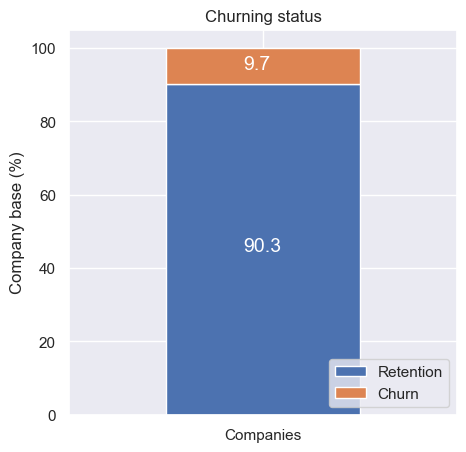

In [47]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

#### Numerical data

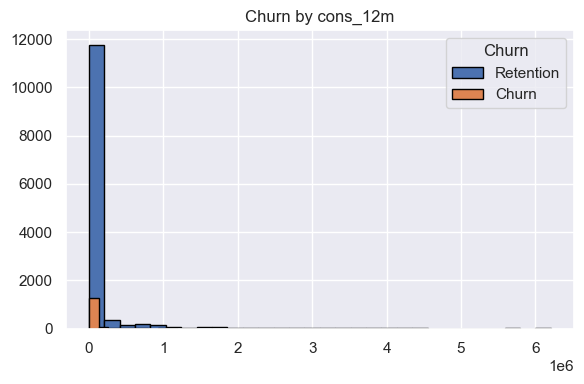

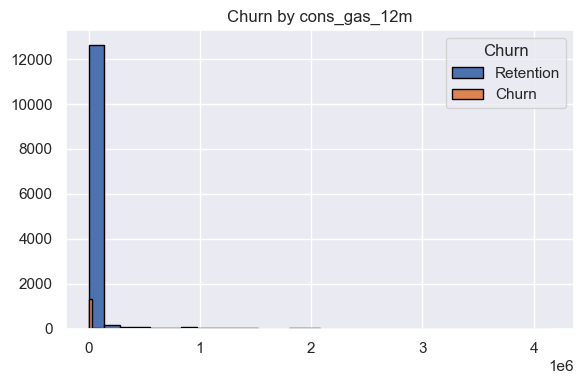

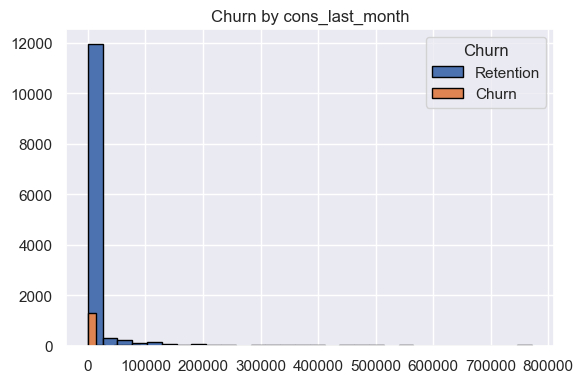

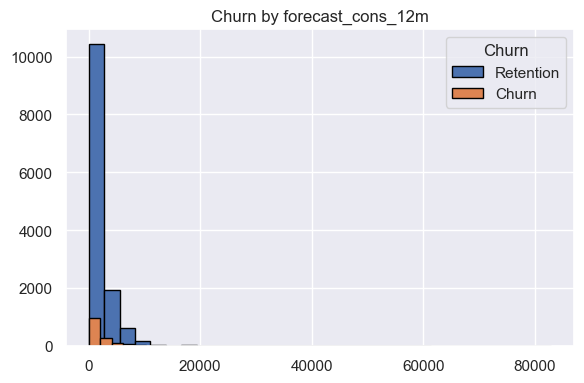

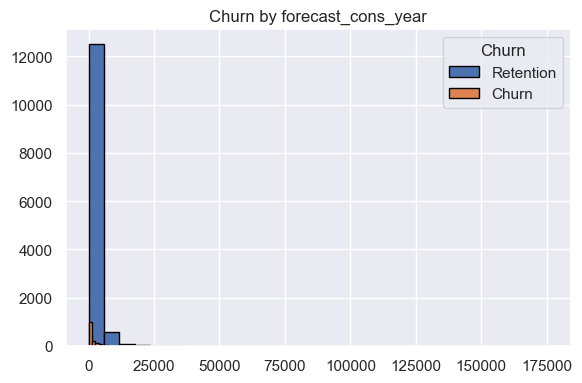

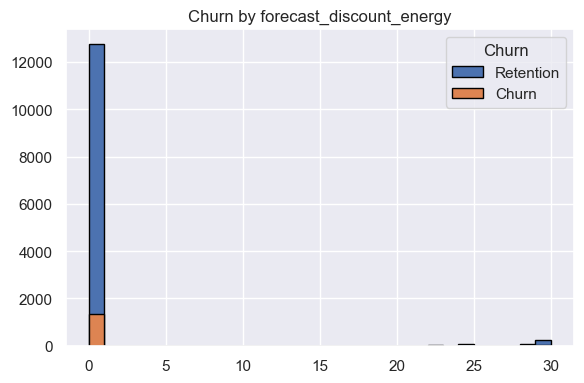

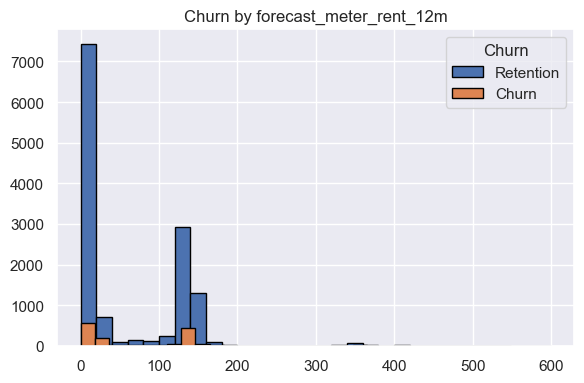

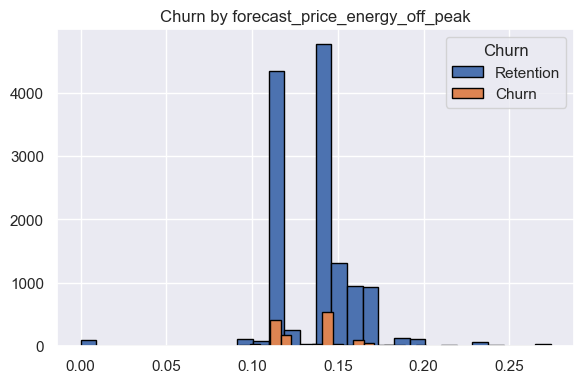

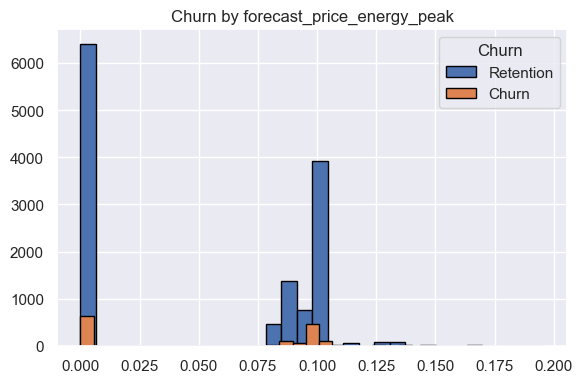

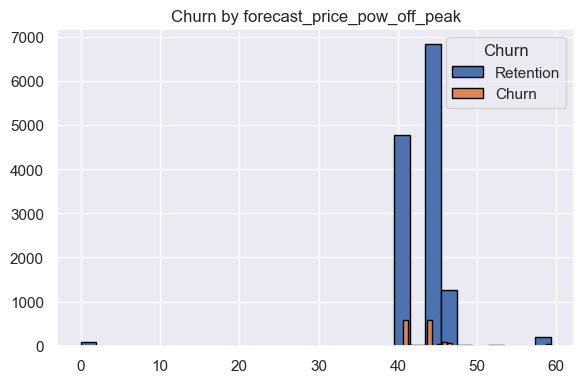

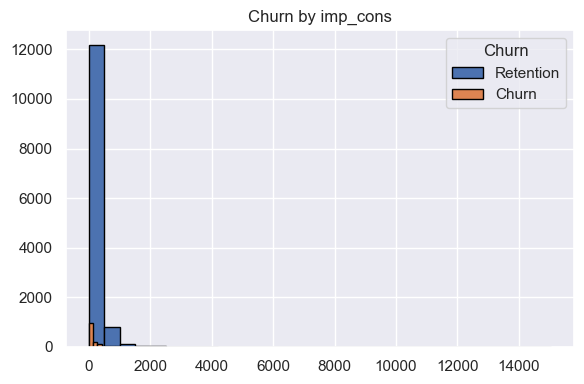

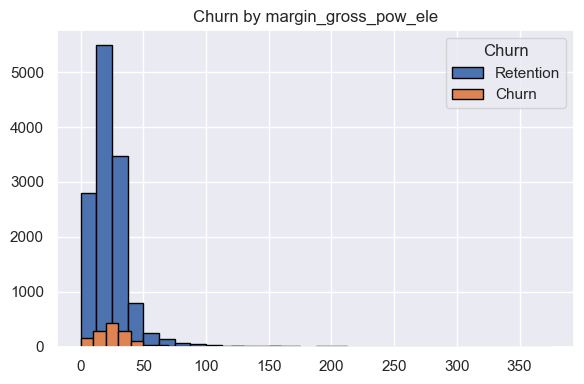

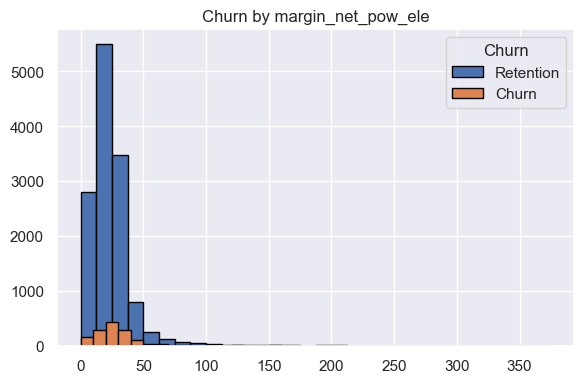

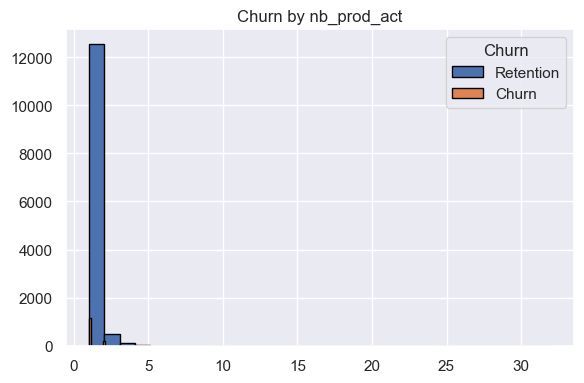

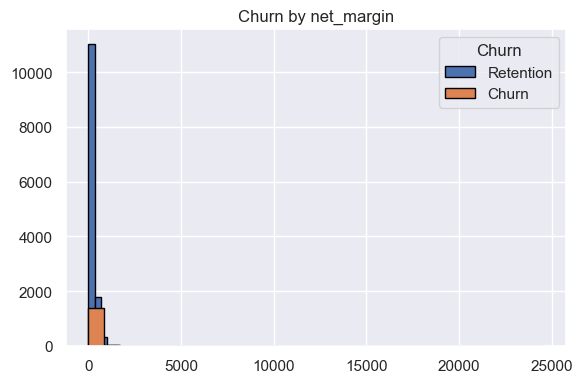

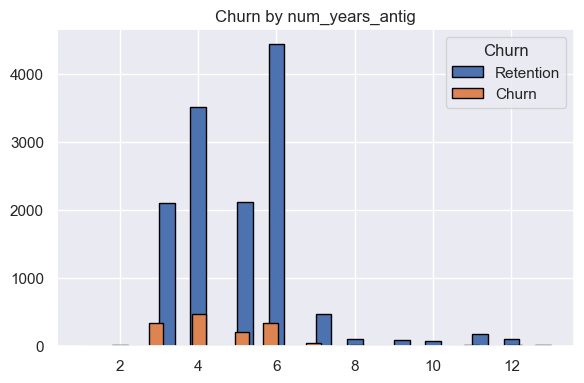

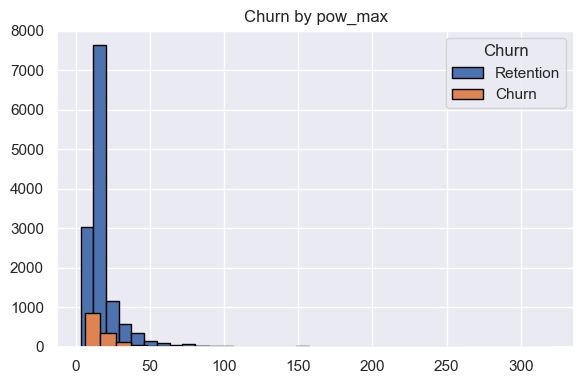

In [48]:
# Consumption(cons) and forecasted cons, price, energy and margin
client_num = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'pow_max']

for col in client_num:
    plt.figure(figsize=(6,4))
    for churn_value in [0, 1]:
       subset = client_df[client_df['churn'] == churn_value]
       plt.hist(subset[col], bins=30, edgecolor= 'black')
    plt.legend(title='Churn', labels=['Retention', 'Churn'])
    plt.title(f'Churn by {col}')
    plt.tight_layout()
    plt.show()

In [50]:
price_df.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

### Price data

To associates the prices with churn, had to merge price data with some churn columns including churn column.

In [ ]:
# keep only id and churn from client_df
client_churn = client_df[['id', 'churn', 'forecast_discount_energy',
      'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 
       'forecast_price_pow_off_peak']]

# Merge with price_df
price_churn_df = price_df.merge(client_churn, on='id', how='left') #need to check my code for merging- Plan on merging data for latest month (December)


rate = price_churn_df.groupby('price_date')['churn'].mean().reset_index(name= 'churn_rate')
rate['retention_rate'] = 1 - rate['churn_rate']
rate.head()

price_churn_df = price_churn_df.merge(rate, on='price_date', how='left' )



In [ ]:
# Convert price date to datetime form
# Extract month and create a new month string column
price_churn_df['price_date'] = pd.to_datetime(price_churn_df['price_date'])
price_churn_df['month_num'] = price_churn_df['price_date'].dt.month

month_dict = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

price_churn_df['month'] = price_churn_df['month_num'].map(month_dict)

price_churn_df

#Convert the newly created dataframe to a csv file
price_churn_df.to_csv("price_df.csv", index=False)

View the first five rows of the updated price data dataframe

In [ ]:
price_churn_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,churn,forecast_discount_energy,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,churn_rate,retention_rate,month_num,month
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0,0.0,0.0,0.14398,0.0,44.311378,0.097148,0.902852,1,January
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0,0.0,0.0,0.14398,0.0,44.311378,0.097150,0.902850,2,February
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0,0.0,0.0,0.14398,0.0,44.311378,0.097046,0.902954,3,March
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0,0.0,0.0,0.14398,0.0,44.311378,0.097108,0.902892,4,April
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0,0.0,0.0,0.14398,0.0,44.311378,0.096916,0.903084,5,May


In [ ]:
# Create churn and retention price variables to use on the visualizations to track churn price and retention over time.
churn_price = price_churn_df[price_churn_df['churn']==1].groupby('price_date').mean(numeric_only=True)
retention_price = price_churn_df[price_churn_df['churn']==0].groupby('price_date').mean(numeric_only=True)

These visuals track churn price and retention from energy and power prices at Mid peak, first peak and off peak

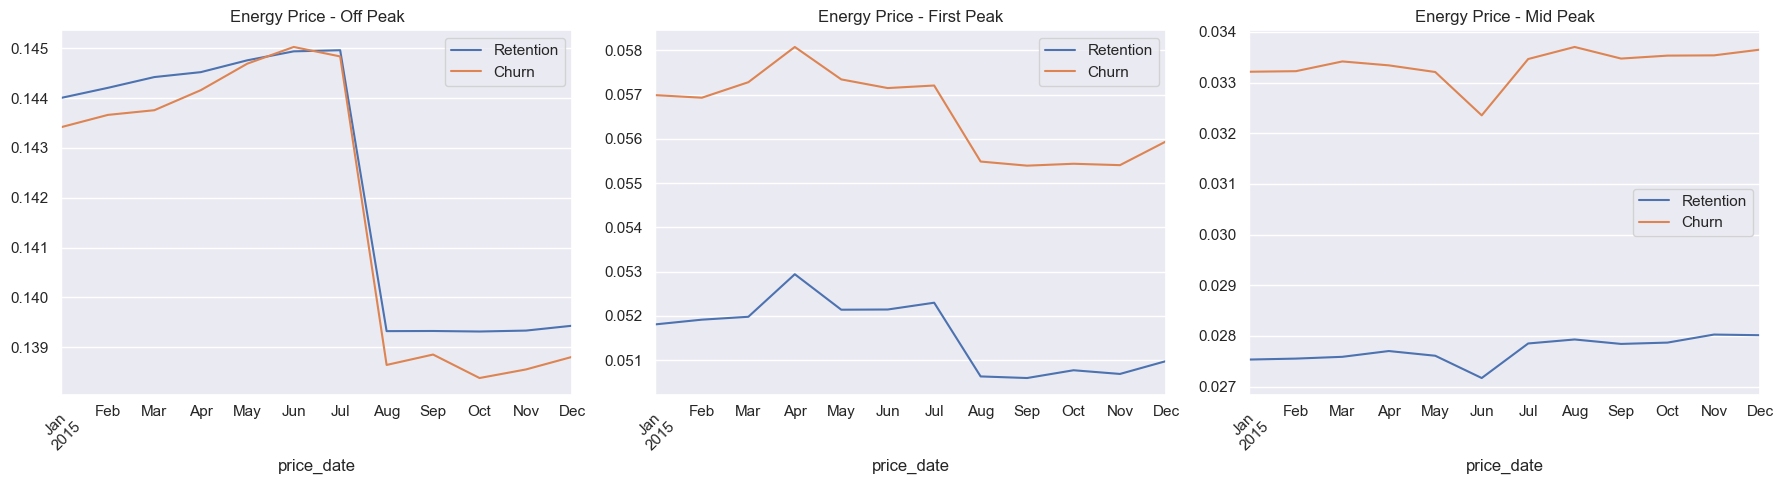

In [ ]:
plt.figure(figsize=(18, 5))

# Energy price - Off Peak
plt.subplot(1, 3, 1)  
retention_price.price_off_peak_var.plot()
churn_price.price_off_peak_var.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Energy Price - Off Peak')

# Energy price - first Peak 
plt.subplot(1, 3, 2) 
retention_price.price_peak_var.plot()
churn_price.price_peak_var.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Energy Price - First Peak')

# Energy price - Mid Peak 
plt.subplot(1, 3, 3)  # position 3
retention_price.price_mid_peak_var.plot()
churn_price.price_mid_peak_var.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Energy Price - Mid Peak')

plt.tight_layout()
plt.show()

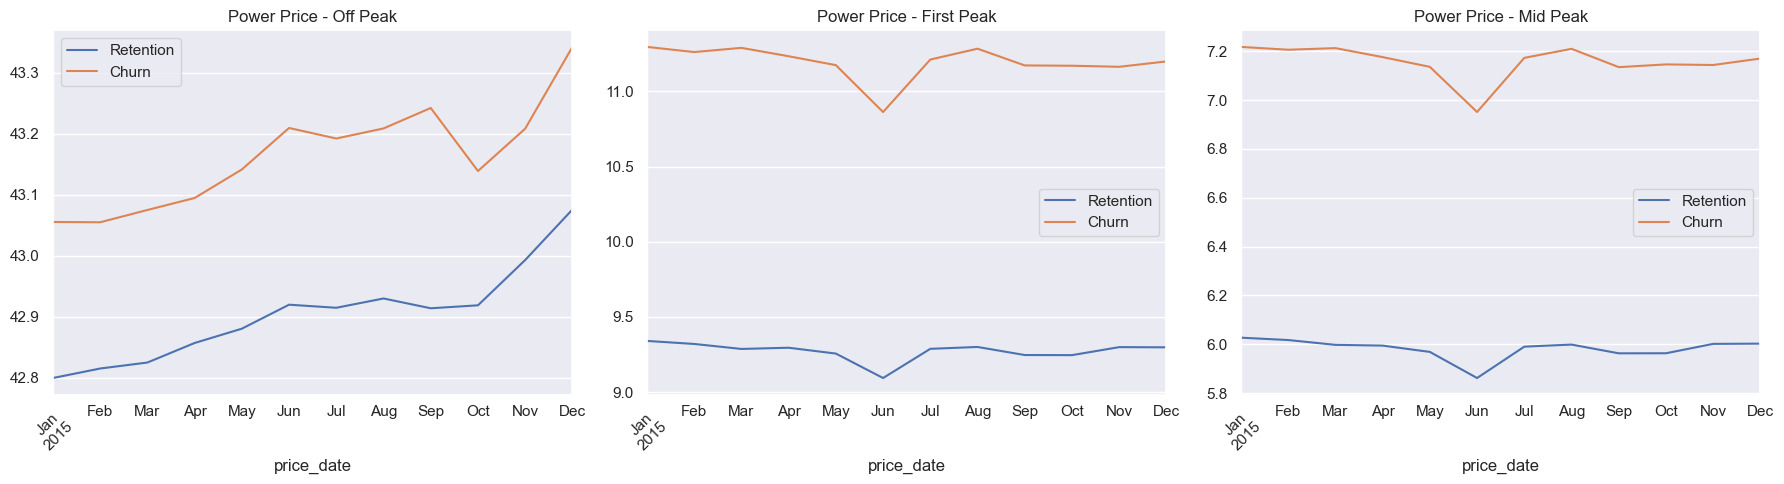

In [ ]:
plt.figure(figsize=(18, 5))

# Power price - Off Peak
plt.subplot(1, 3, 1)  
retention_price.price_off_peak_fix.plot()
churn_price.price_off_peak_fix.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Power Price - Off Peak')

# Power price - first Peak 
plt.subplot(1, 3, 2) 
retention_price.price_peak_fix.plot()
churn_price.price_peak_fix.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Power Price - First Peak')

# Power price - Mid Peak 
plt.subplot(1, 3, 3)  # position 3
retention_price.price_mid_peak_fix.plot()
churn_price.price_mid_peak_fix.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Power Price - Mid Peak')

plt.tight_layout()
plt.show()

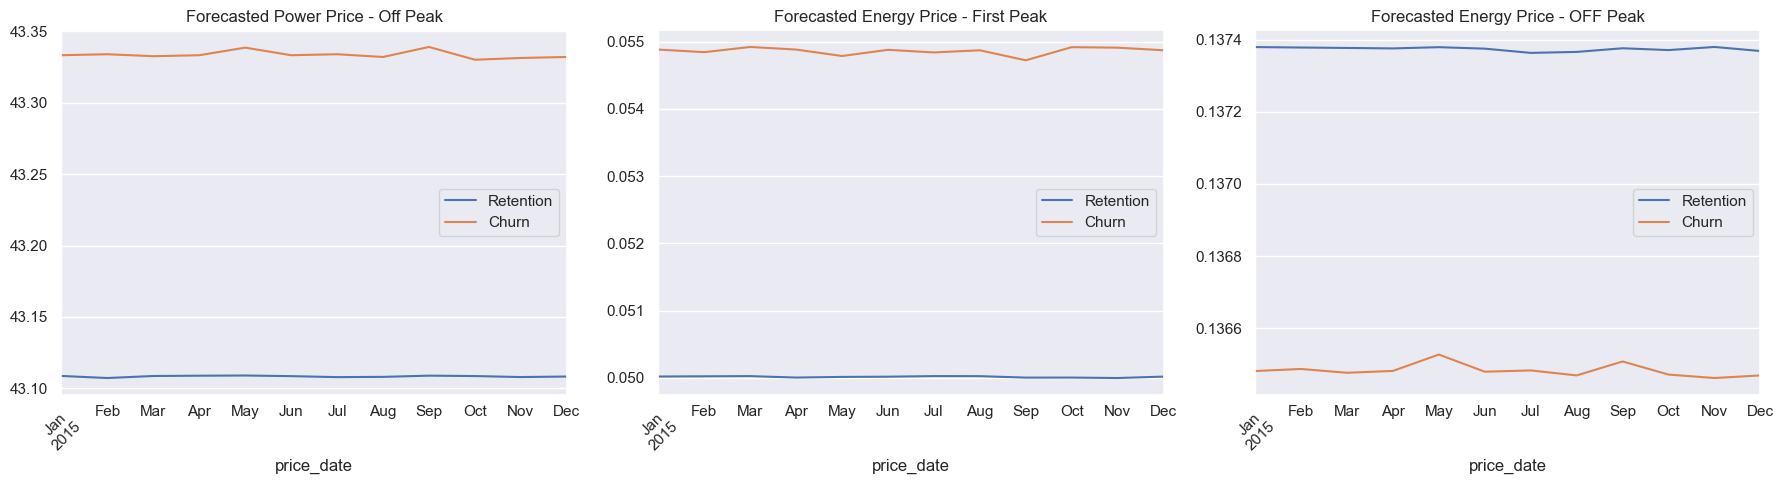

In [ ]:
plt.figure(figsize=(18, 5))

# Energy price - Off Peak
plt.subplot(1, 3, 1)  
retention_price.forecast_price_pow_off_peak.plot()
churn_price.forecast_price_pow_off_peak.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Forecasted Power Price - Off Peak')

# Energy price - first Peak 
plt.subplot(1, 3, 2) 
retention_price.forecast_price_energy_peak.plot()
churn_price.forecast_price_energy_peak.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Forecasted Energy Price - First Peak')

# Energy price - Mid Peak 
plt.subplot(1, 3, 3)  # position 3
retention_price.forecast_price_energy_off_peak.plot()
churn_price.forecast_price_energy_off_peak.plot()
plt.xticks(rotation=45)
plt.legend(['Retention', 'Churn'])
plt.title('Forecasted Energy Price - OFF Peak')

plt.tight_layout()
plt.show()

### Merged price data and client data 
Only Using data for the last month of the year as it is the most recent.


In [ ]:

customer_data = client_df.merge(price_df, on='id')

customer_data['price_date'] = pd.to_datetime(customer_data['price_date'])

customer_data = customer_data[customer_data['price_date'] == '2015-12-01']

Check the merged data (customer data) data types and stats using info() and describe() respectively.

In [ ]:
display(customer_data.describe().T, customer_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14604 entries, 11 to 175148
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14604 non-null  object        
 1   channel_sales                   14604 non-null  object        
 2   cons_12m                        14604 non-null  int64         
 3   cons_gas_12m                    14604 non-null  int64         
 4   cons_last_month                 14604 non-null  int64         
 5   date_activ                      14604 non-null  object        
 6   date_end                        14604 non-null  object        
 7   date_modif_prod                 14604 non-null  object        
 8   date_renewal                    14604 non-null  object        
 9   forecast_cons_12m               14604 non-null  float64       
 10  forecast_cons_year              14604 non-null  int64         
 11  forec

,count,mean,min,25%,50%,75%,max,std
cons_12m,14604.0,159240.816626,0.0,5676.25,14117.0,40766.25,6207104.0,573501.847323
cons_gas_12m,14604.0,28092.980416,0.0,0.0,0.0,0.0,4154590.0,162983.982617
cons_last_month,14604.0,16092.473295,0.0,0.0,793.0,3383.0,771203.0,64368.328404
forecast_cons_12m,14604.0,1868.712612,0.0,494.9375,1112.875,2402.3125,82902.83,2387.716554
forecast_cons_year,14604.0,1399.954601,0.0,0.0,314.0,1746.0,175375.0,3247.967338
forecast_discount_energy,14604.0,0.966516,0.0,0.0,0.0,0.0,30.0,5.108523
forecast_meter_rent_12m,14604.0,63.094768,0.0,16.18,18.8,131.03,599.31,66.166842
forecast_price_energy_off_peak,14604.0,0.137281,0.0,0.11634,0.143166,0.146348,0.273963,0.024624
forecast_price_energy_peak,14604.0,0.050492,0.0,0.0,0.084138,0.098837,0.195975,0.049037
forecast_price_pow_off_peak,14604.0,43.130005,0.0,40.606701,44.311378,44.311378,59.266378,4.486283


None

Check for missing values from the customer data

In [ ]:
customer_data.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
price_date                        0
price_off_peak_var          

Check for duplicates from the customer data

In [ ]:
customer_data.duplicated().sum()

0

In [ ]:
# Customer data columns
customer_data.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn',
       'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

## Multivariate Analysis
### Numerical data

Used Correlation Heatmap to visualise the relationship between the predictors and True value.

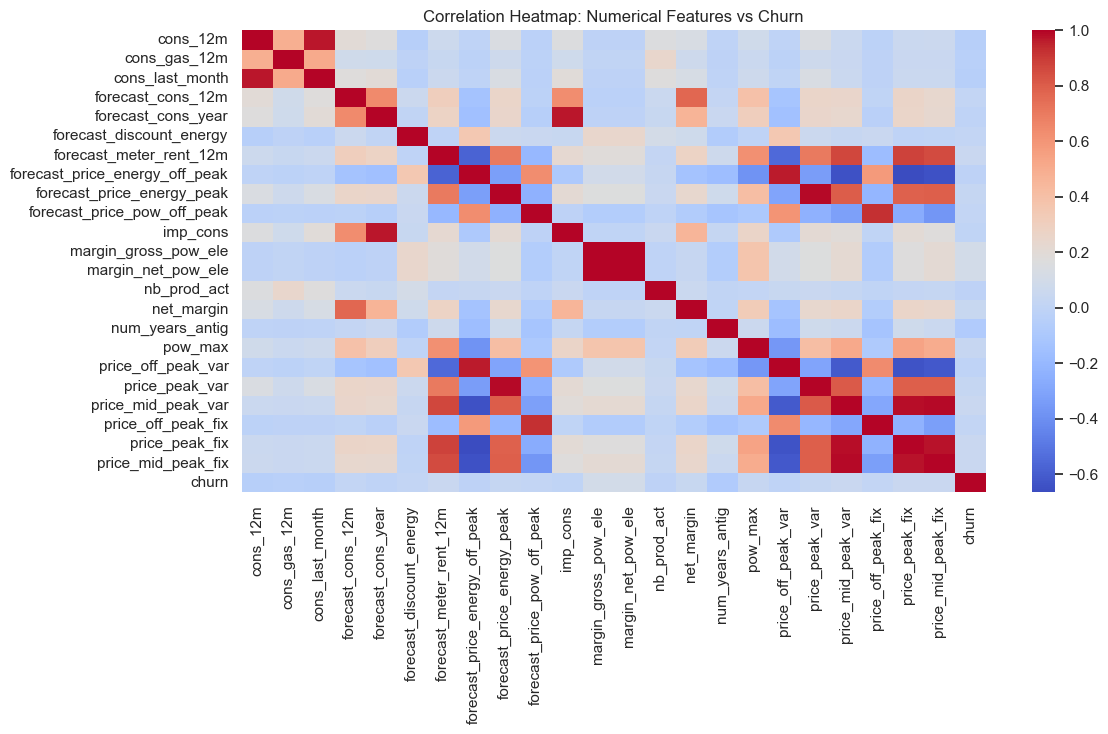

In [ ]:
num_cols = [
    'cons_12m','cons_gas_12m','cons_last_month','forecast_cons_12m',
    'forecast_cons_year','forecast_discount_energy','forecast_meter_rent_12m',
    'forecast_price_energy_off_peak','forecast_price_energy_peak',
    'forecast_price_pow_off_peak','imp_cons','margin_gross_pow_ele',
    'margin_net_pow_ele','nb_prod_act','net_margin','num_years_antig','pow_max',
    'price_off_peak_var','price_peak_var','price_mid_peak_var',
    'price_off_peak_fix','price_peak_fix','price_mid_peak_fix'
]

plt.figure(figsize=(12,6))
sns.heatmap(customer_data[num_cols + ['churn']].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap: Numerical Features vs Churn")
plt.show()

The pairwise plot was to further look into the multicollinearity in the predictors.

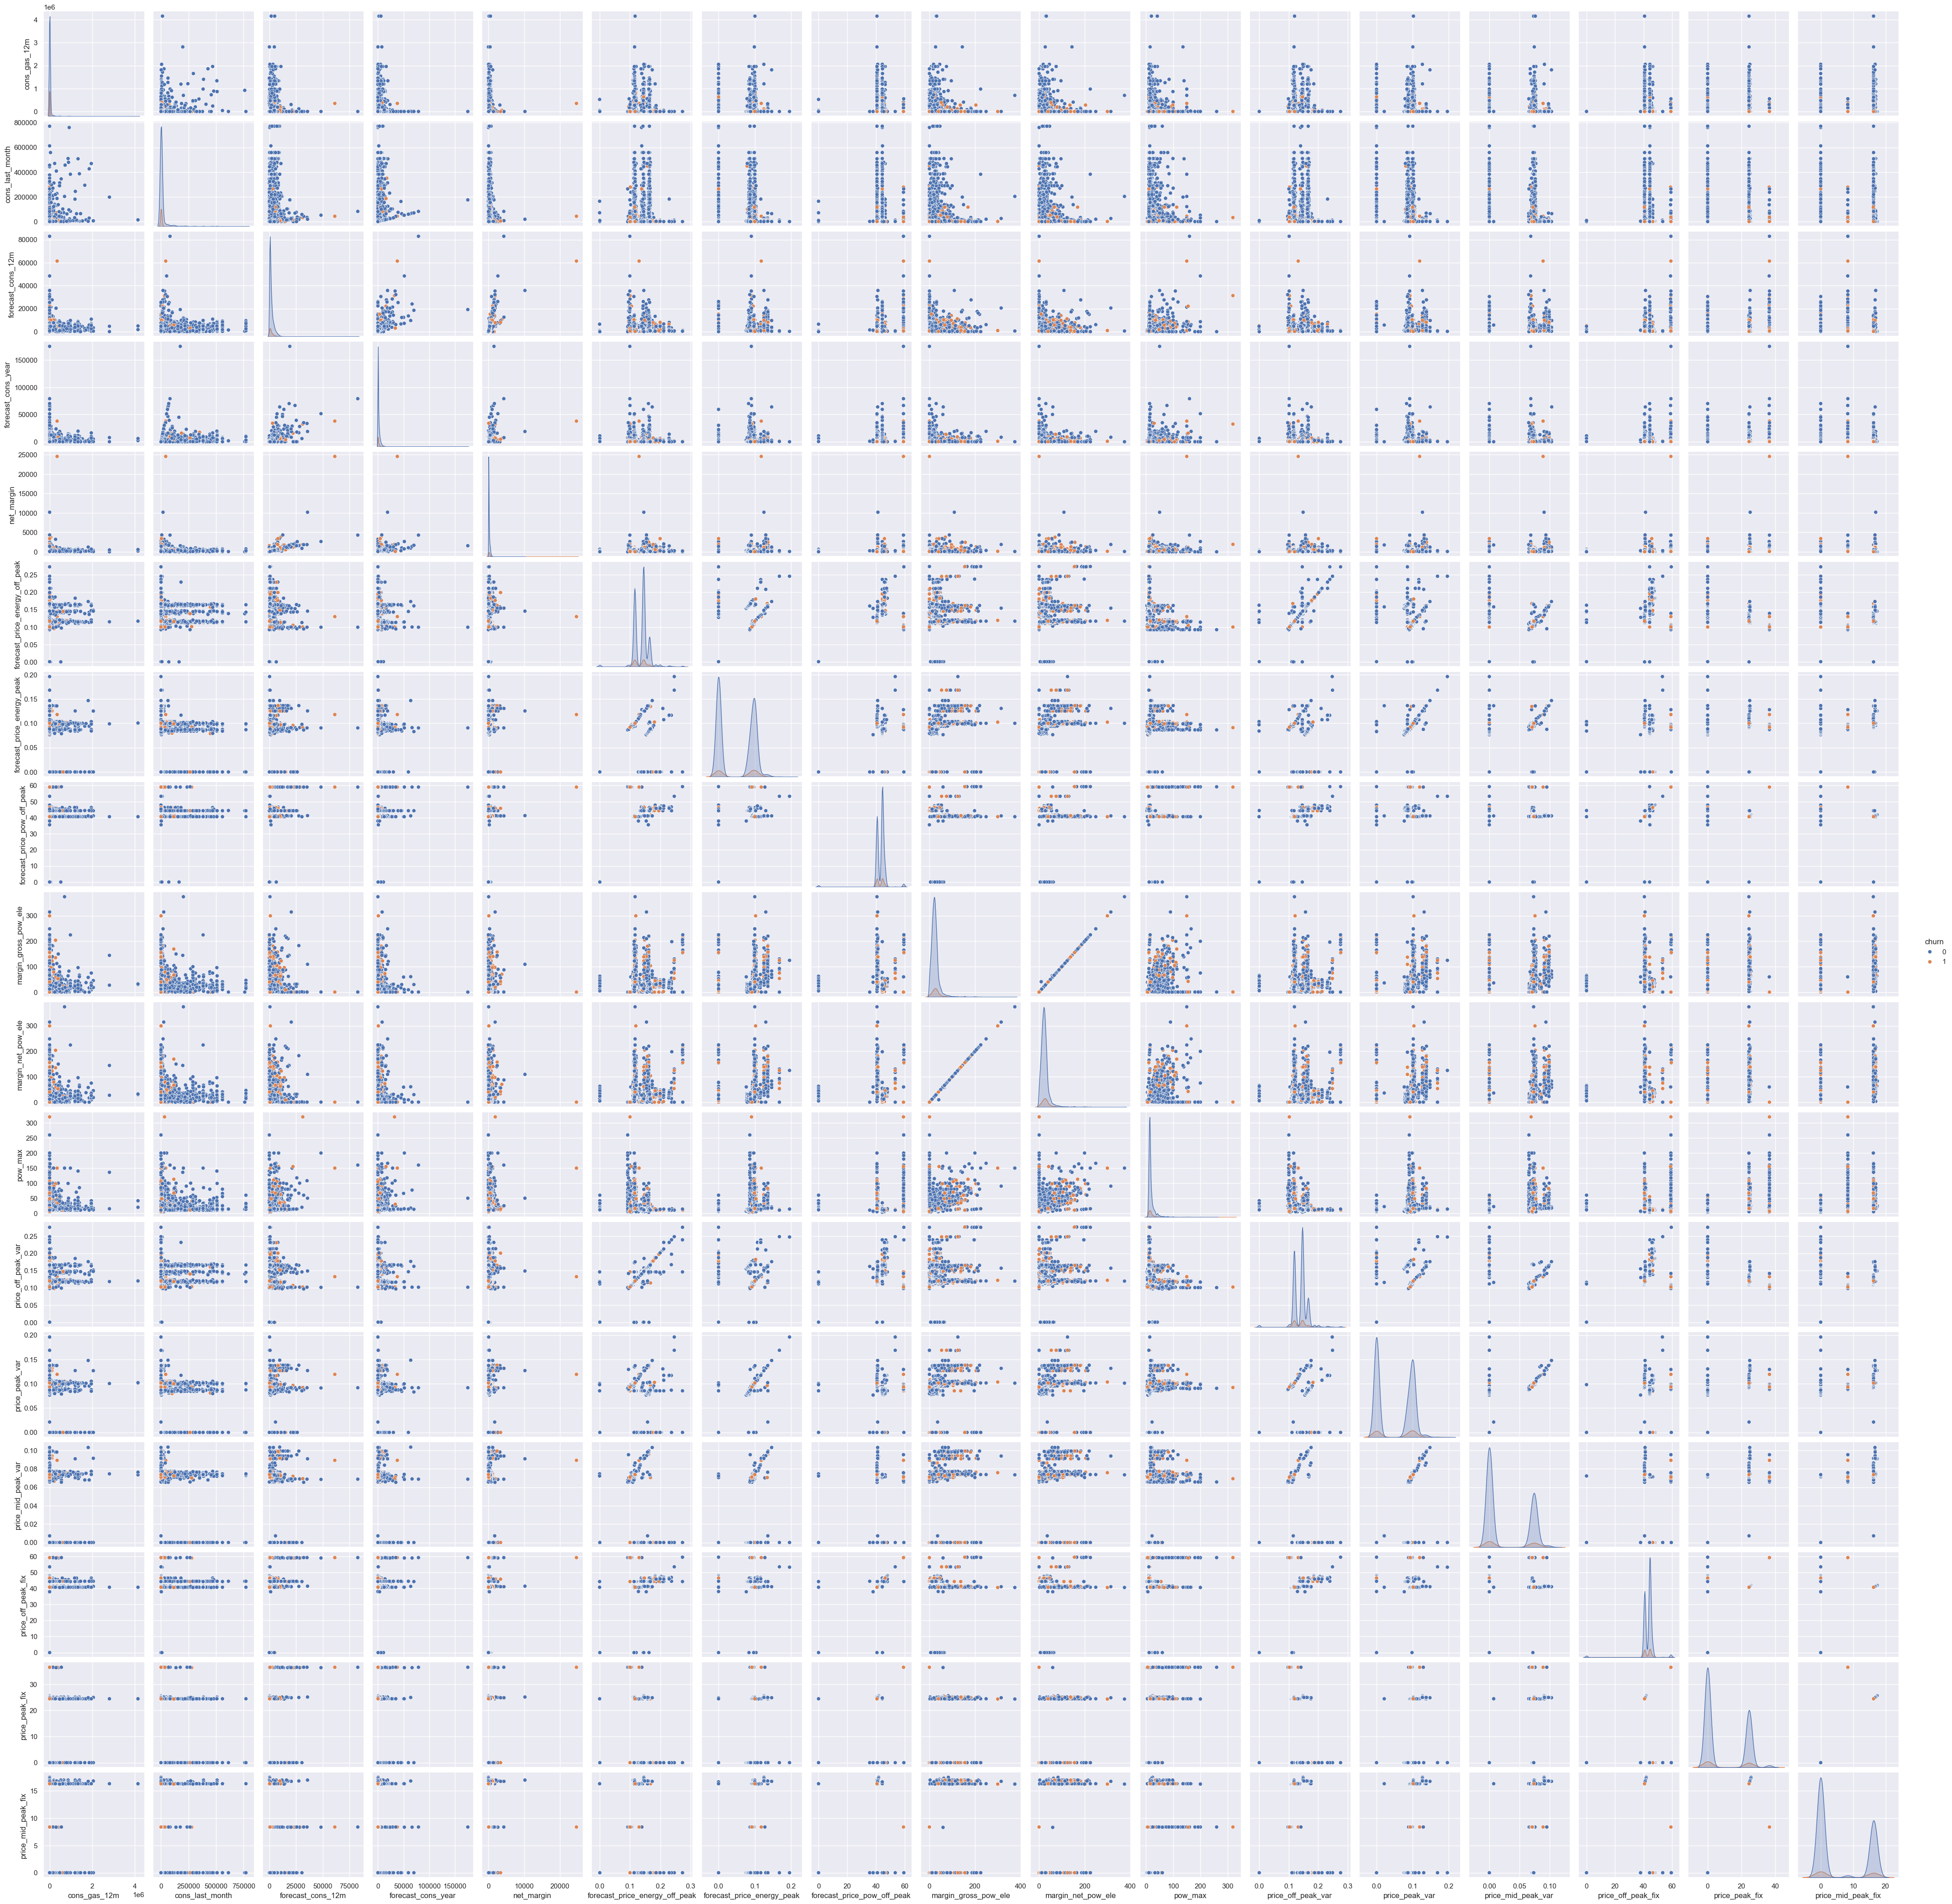

In [ ]:
sns.pairplot(customer_data,
             vars=['cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'net_margin', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'pow_max', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
             hue='churn',
             diag_kind='kde')
plt.show()

In [ ]:

# 1. Calculate correlation matrix
numeric_df = customer_data.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# 2. Select upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 3. Find features with correlation higher than threshold
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.8)]

print("Highly correlated features to drop:")
print(to_drop)

# 4. Drop those features from dataset
reduced_df = customer_data.drop(columns=to_drop)

print("Remaining predictors:", reduced_df.columns.tolist())

Highly correlated features to drop:
['cons_last_month', 'imp_cons', 'margin_net_pow_ele', 'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
Remaining predictors: ['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas', 'margin_gross_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn', 'price_date']


### Catagorical data
Highlights of categories most churn prone from given data/columns

##### Channel sales

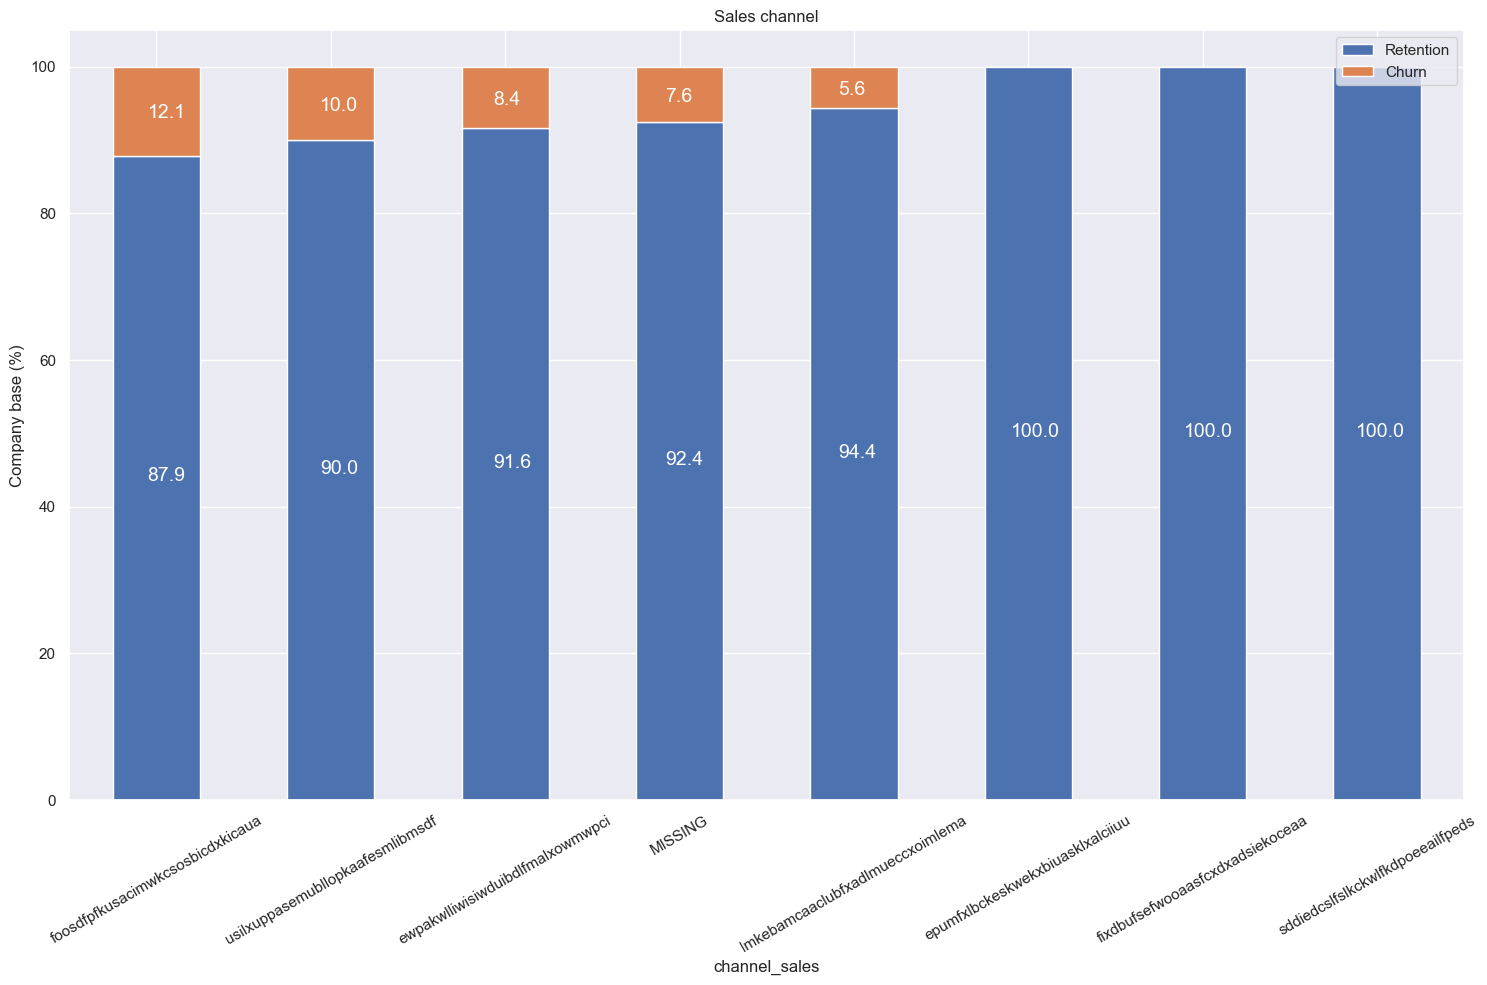

In [ ]:
channel = client_df[['id', 'channel_sales', 'churn']]
channel = channel.groupby([channel['channel_sales'], channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

plot_stacked_bars(channel_churn, 'Sales channel', rot_=30)

##### Gas availability

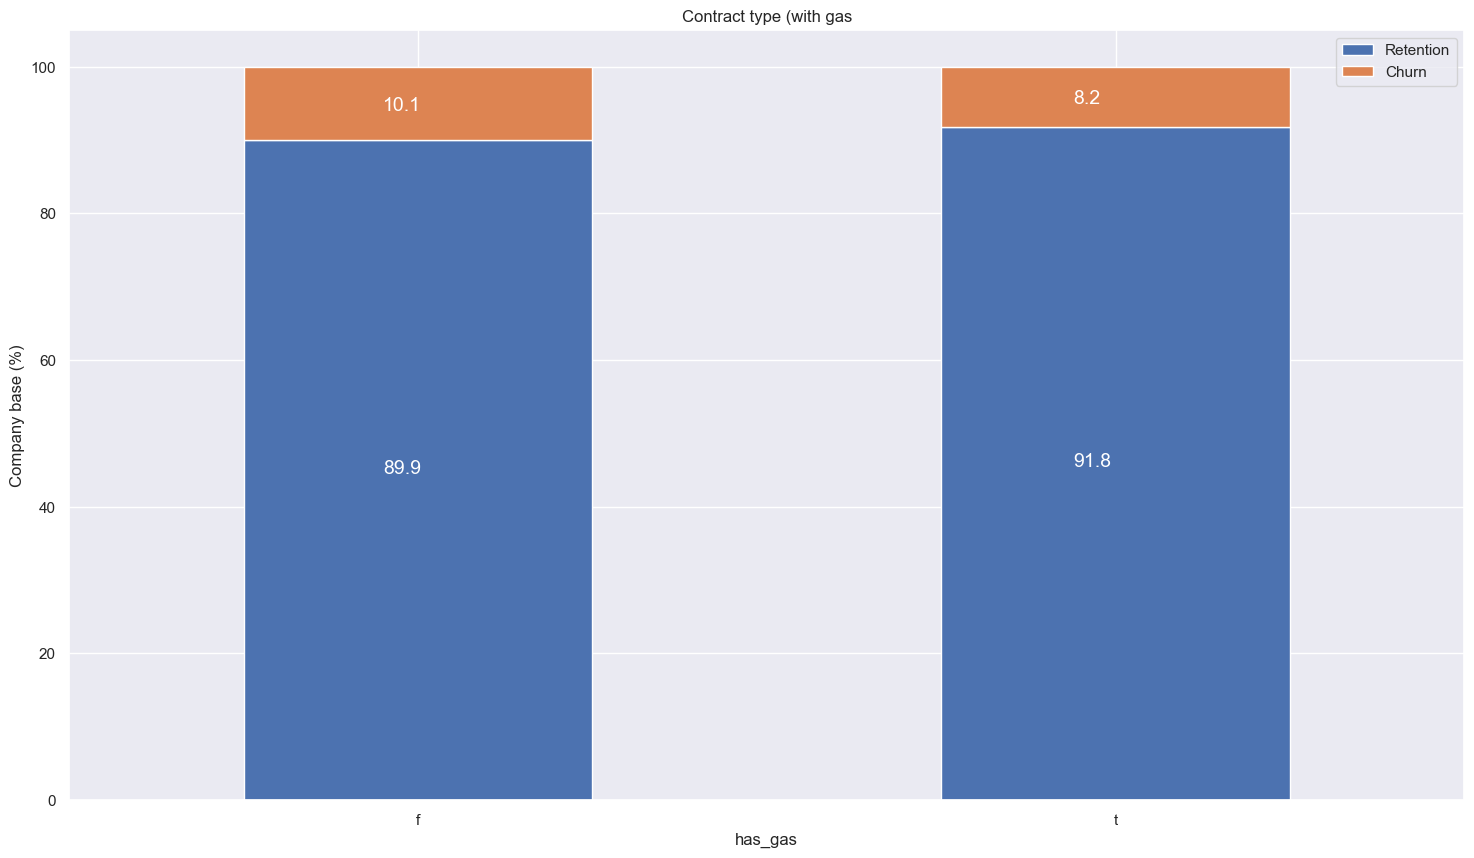

In [ ]:
gas_availability = client_df[['id', 'has_gas', 'churn']]
contract = gas_availability .groupby([gas_availability ['churn'], gas_availability['has_gas']])['id'].count().unstack(level=0)
gas_availability_percentage = (contract.div(contract.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

plot_stacked_bars(gas_availability_percentage, 'Contract type (with gas')

##### Origin up

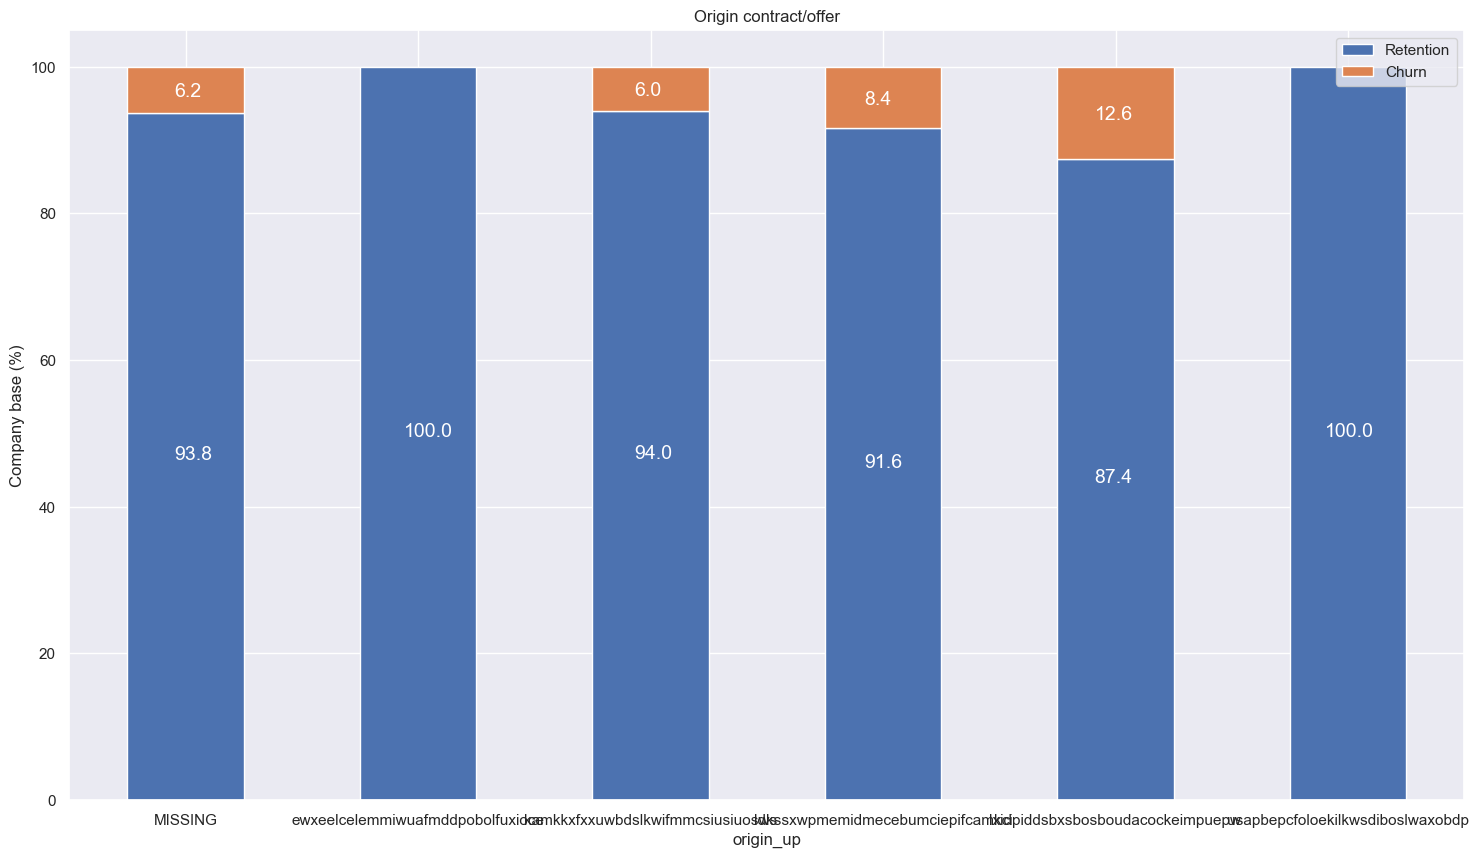

In [ ]:
origin = client_df[['id', 'origin_up', 'churn']]
origin = origin.groupby([origin["origin_up"],origin["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer")

Used feature importance to find the most important features from the predictors in the customer data

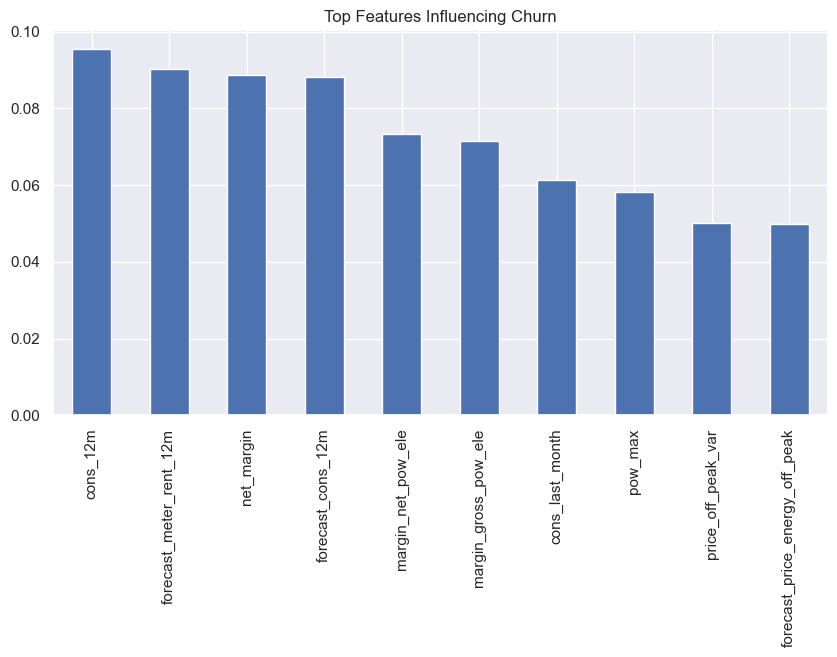

In [ ]:
X = customer_data[num_cols].fillna(0)   
y = customer_data['churn']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=num_cols).sort_values(ascending=False)
importances.head(10).plot(kind='bar', figsize=(10,5), title="Top Features Influencing Churn")
plt.show()